[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/viscoelastic-startup/blob/main/notebooks/balan_2023_startup_couette.ipynb)

# LEARNING OBJECTIVE

After exploring this notebook, you will be able to reproduce the start-up of plane Couette flow of the three-constant Gordon&ndash;Schowalter fluid as formulated by [Balan (2023)](https://doi.org/10.1063/5.0173510), and show that its initial data, the plate already moving at $t = 0$ while the shear stress is zero, are inconsistent with a retardation time. Furthermore, you will be able to prove with the Laplace transform that, for the Oldroyd-B case ($a = 1$), they turn the problem into the start-up of a plate ramped on the retardation timescale, and to compare Balan's figures with the exact solutions of both problems, the consistent start-up and the ramped plate.

The lesson here is that initial data carry the start-up jump just as the boundary condition does: with a retardation time, the plate's velocity and the total stress cannot be prescribed independently at $t = 0$. Data that set the total stress to zero describe a plate ramped on $\lambda_2$, the ramped plate of the other notebooks, reached through initial data rather than a transform.

# PRELIMINARIES

This notebook uses [NumPy](https://numpy.org) ([Harris _et al._, 2020](https://doi.org/10.1038/s41586-020-2649-2)), [SciPy](https://scipy.org) ([Virtanen _et al._, 2020](https://doi.org/10.1038/s41592-019-0686-2)), [SymPy](https://www.sympy.org) ([Meurer _et al._, 2017](https://doi.org/10.7717/peerj-cs.103)), [Matplotlib](https://matplotlib.org) ([Hunter, 2007](https://doi.org/10.1109/MCSE.2007.55)) and [mpmath](https://mpmath.org) ([mpmath development team, 2023](https://mpmath.org/)).

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# for animations
from IPython.display import HTML

# numerics
import numpy as np
from scipy.linalg import solve_banded
from scipy.integrate import quad
from scipy.optimize import brentq
from scipy.special import erfc
import mpmath as mp
import os

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version of this notebook written by [Ivan C. Christov](https://christov.tmnt-lab.org), Purdue University.

Reproducing results of C. Balan.

# THE PROBLEM

Balan (2023) writes the start-up of simple shear of a three-constant Gordon&ndash;Schowalter (Jeffreys-type) fluid ([Gordon & Schowalter, 1972](https://doi.org/10.1122/1.549256); [Johnson & Segalman, 1977](https://doi.org/10.1016/0377-0257%2877%2980003-7)) as a system for the velocity $v(x,t)$, the shear stress $\sigma(x,t)$ and a normal-stress combination $N(x,t)$, his Eqs. (5)&ndash;(7):
\begin{align*}
    \mathrm{Re}\,\frac{\partial v}{\partial t} &= \frac{\partial \sigma}{\partial x},\\
    \frac{\partial N}{\partial t} + N &= 2(1-a^2)\left[\sigma\frac{\partial v}{\partial x} - \kappa\left(\frac{\partial v}{\partial x}\right)^2\right],\\
    \frac{\partial \sigma}{\partial t} + \sigma &= \kappa\frac{\partial^2 v}{\partial x\partial t} - \left(\frac{N}{2} - 1\right)\frac{\partial v}{\partial x},
\end{align*}
with velocity, length, time and stress scaled by $v_0$, $h$, $\lambda_1$ and $\eta_0/\lambda_1$, $\mathrm{Re} = \rho v_0h/\eta_0$ (and $\lambda_1v_0/h = 1$), $\kappa = \lambda_2/\lambda_1$ the ratio of the retardation and relaxation times, and $a\in[-1,1]$ the slip parameter ($a = 1$: Oldroyd-B; $a = 0$: corotational (Jaumann)). For $a = 1$ and $N(x,0) = 0$, $N \equiv 0$ and the system collapses to his Eq. (8),
$$
    \mathrm{Re}\left(\frac{\partial^2 v}{\partial t^2} + \frac{\partial v}{\partial t}\right) = \kappa\frac{\partial^3 v}{\partial x^2\partial t} + \frac{\partial^2 v}{\partial x^2},
$$
the Oldroyd-B (Jeffreys) start-up problem. Below, $a = 1$, $\mathrm{Re} = 1$, and the moving plate is at $x = x_0$; the solution is shown against the distance $\xi = x_0 - x$ from the plate.

The system is solved by finite differences in the polymer-stress form $S = \sigma - \kappa\,\partial v/\partial x$, which removes the mixed derivative:
\begin{align*}
    \mathrm{Re}\,\frac{\partial v}{\partial t} &= \frac{\partial S}{\partial x} + \kappa\frac{\partial^2 v}{\partial x^2},\\
    \frac{\partial S}{\partial t} + S &= \left(1 - \kappa - \frac{N}{2}\right)\frac{\partial v}{\partial x},\\
    \frac{\partial N}{\partial t} + N &= 2(1-a^2)\,S\,\frac{\partial v}{\partial x},
\end{align*}
with $v$ at the nodes and $S$, $N$ at the cell centers, and one time-stepping rule throughout: the trapezoidal rule, which on the solvent diffusion is Crank&ndash;Nicolson ([Crank & Nicolson, 1947](https://doi.org/10.1017/S0305004100023197)), and which likewise averages the stress divergence $\partial S/\partial x$ and advances $S$ and $N$. Their coupling, nonlinear for $a \ne \pm1$, is resolved by three sweeps per step, $v$, then $S$, then $N$, each on the values just updated; the first four steps are backward Euler steps ([Rannacher, 1984](https://doi.org/10.1007/BF01390130)). Output times between two steps are interpolated linearly. The scheme is formally $O[(\Delta t)^2 + (\Delta x)^2]$, but first order in practice near the plate, because of the start-up jump.

In [2]:
# Finite differences for Eqs. (5)-(7) of Balan (2023): startup_fd, polymer-stress form
def startup_fd(M=400, a=1.0, kappa=0.01, Re=1.0, tmax=5.0, L=1.0, dt=None, sample_t=None, sample_x=None,
               inconsistent_ic=False, N0=0.0, n_rannacher=4, n_iter=3, wall_N=None, wall_sigma=None, sample_sigma=None):
    """Start-up plane Couette flow of the Gordon-Schowalter fluid, Eqs. (5)-(7) of Balan (2023), in (v, S, N); plate at x = L."""
    # inconsistent_ic = True imposes sigma(x, 0) = 0 with the plate already moving, Eqs. (9)-(10) of Balan (2023)
    # N0 is the initial normal stress, N(x, 0) = N0 of Eq. (10)(v); Balan takes N0 = 0 for the runs reproduced here
    # wall_N and wall_sigma, if lists, receive N and sigma = S + kappa dv/dx in the cell next to the plate after every time step;
    # sample_sigma, if a list, receives the sigma profile at sample_x for each sample_t, as samples does for v
    dx = L/M
    if dt is None:
        dt = 0.5*dx*min(1.0, np.sqrt(Re))
    nsteps = int(np.ceil(tmax/dt))
    dt = tmax/nsteps
    x = np.linspace(0, L, M+1)
    v = np.zeros(M+1)
    S = np.zeros(M)
    N = np.full(M, N0)
    v[-1] = 1.0
    if inconsistent_ic:
        S[-1] = -kappa*(v[-1] - v[-2])/dx   # total stress sigma = S + kappa dv/dx = 0 in the cell at the plate
    # tridiagonal matrices for Crank-Nicolson (theta = 1/2) and backward Euler (theta = 1)
    r_cn = 0.5*kappa*dt/(Re*dx**2)
    ab_cn = np.zeros((3, M-1))
    ab_cn[0, 1:] = -r_cn
    ab_cn[1, :] = 1 + 2*r_cn
    ab_cn[2, :-1] = -r_cn
    r_be = kappa*dt/(Re*dx**2)
    ab_be = np.zeros((3, M-1))
    ab_be[0, 1:] = -r_be
    ab_be[1, :] = 1 + 2*r_be
    ab_be[2, :-1] = -r_be
    samples = []
    next_out = 0
    ts = 0.0
    for n in range(nsteps):
        g = np.diff(v)/dx
        dS = -S + (1 - kappa - N/2)*g
        dN = -N + 2*(1 - a**2)*S*g
        Sp = S + dt*dS
        Np = N + dt*dN
        if n < n_rannacher:
            r = r_be
            ab = ab_be
        else:
            r = r_cn
            ab = ab_cn
        vb = v.copy()
        # iterate the trapezoidal stress update and the implicit velocity update a few times
        for it in range(n_iter):
            Sm = 0.5*(S + Sp)
            rhs = v[1:-1] + dt/Re*np.diff(Sm)/dx
            if n >= n_rannacher:
                rhs = rhs + r*(v[2:] - 2*v[1:-1] + v[:-2])
            rhs[0] = rhs[0] + r*vb[0]
            rhs[-1] = rhs[-1] + r*vb[-1]
            vb[1:-1] = solve_banded((1, 1), ab, rhs)
            gp = np.diff(vb)/dx
            Sp = S + 0.5*dt*(dS + (-Sp + (1 - kappa - Np/2)*gp))
            Np = N + 0.5*dt*(dN + (-Np + 2*(1 - a**2)*Sp*gp))
        # record the requested output times, interpolating linearly between the two time levels
        while sample_t is not None and next_out < len(sample_t) and ts + dt >= sample_t[next_out] - 1e-12:
            weight = (sample_t[next_out] - ts)/dt
            v_out = (1 - weight)*v + weight*vb
            if sample_x is None:
                samples.append(v_out)
            else:
                samples.append(np.interp(sample_x, x, v_out))
            if sample_sigma is not None:
                # sigma = S + kappa dv/dx at the cell centers, interpolated to the output time as v is
                sigma_out = (1 - weight)*(S + kappa*np.diff(v)/dx) + weight*(Sp + kappa*np.diff(vb)/dx)
                sample_sigma.append(np.interp(sample_x, x[:-1] + dx/2, sigma_out))
            next_out = next_out + 1
        S = Sp
        N = Np
        v = vb
        ts = ts + dt
        if wall_N is not None:
            wall_N.append(N[-1])
        if wall_sigma is not None:
            wall_sigma.append(S[-1] + kappa*(v[-1] - v[-2])/dx)
    return x, v, np.array(samples)

The solvent stress $\kappa\,\partial v/\partial x$ has no memory: when the plate jumps from rest to $v = 1$ at $t = 0^+$, it responds instantly, with $\sigma = \kappa\,\delta(x - x_0)$ at that instant, while the polymer stress $S$ starts from zero and builds up on the relaxation time. Initial data for a fluid with $\kappa > 0$ must respect this split, and Balan's do not.

# THE INCONSISTENT INITIAL DATA

> &#x26A0;&#xFE0F; **INCONSISTENT INITIAL DATA, reproduced as printed** in Eqs. (9)&ndash;(10) of Balan (2023), p. 113108-5:
\begin{align*}
    &\text{(i) } v(x_0,t) = v_0 = 1,\qquad\qquad\quad\; \text{(ii) } v(0,t) = 0, & t > 0,\\
    &\text{(iii) } v(x,0) = v_0\cdot\mathrm{H}[x - x_0],\qquad \text{(iv) } \sigma(x,0) = \sigma_0 = 0,\qquad \text{(v) } N(x,0) = N_0, &\quad 0 \le x \le x_0,
\end{align*}

With $\kappa > 0$ the plate velocity at $t = 0$ and the zero total stress are incompatible: the solvent stress $\kappa\,\partial v/\partial x$ of a velocity jump at the plate is a delta function, so $\sigma(x,0) = 0$ prescribes a fictitious polymer stress $S(x,0) = -\kappa\,\delta(x - x_0)$, which then relaxes on the relaxation time. It is shown below that these data solve a different problem.

On the domain $0\le x\le x_0$, (iii) is zero except at the plate, $x = x_0$, so it only restates (i) at $t = 0$: the plate is already moving when the fluid, at rest and unstressed, is released. (Balan writes $\bar{x}$ for the position of the moving plate; it is $x_0$ here, because an overbar denotes the Laplace transform below, as it does in the Comment. Correcting an inconsistency in his Sect. II.B, which says that "$x = 0$ indicates the position of the plate", with $v(0,t) = v_0$: in Eq. (9) and in his figures the plate at $x = x_0$ moves and $x = 0$ is fixed, as here.)

Balan takes $N_0 = 0$ for the start-up computations reproduced here: on p. 113108-5, just below Eqs. (9)&ndash;(10), &ldquo;one considers in this paper a large gap, $\bar{x} = 100$, $\mathrm{Re} = 1$, and the associated boundary conditions (9) and (10) with $N_0 = 0$&rdquo;. His $N_0 > 0$ cases belong to the flow-curve and shear-banding sections, which are not reproduced here, so `startup_fd` always starts from $N = 0$ and takes no $N_0$.

In `startup_fd`, these data are `inconsistent_ic=True`; the next cell wraps it for the distances $\xi$ from the plate.

In [3]:
# INCONSISTENT, as printed: Eqs. (9)-(10) of Balan (2023), solved by startup_fd
def inconsistent_balan_9_10(xi, times, kappa, Re=1.0, a=1.0, L=20.0, M=2000, sample_sigma=None):
    """Solution for the initial data of Eqs. (9)-(10) of Balan (2023) at the distances xi (an array) from the plate."""
    x, v, samples = startup_fd(M=M, a=a, kappa=kappa, Re=Re, tmax=times[-1], L=L,
                               sample_t=times, sample_x=L - xi, inconsistent_ic=True, sample_sigma=sample_sigma)
    return samples

> &#x26A0;&#xFE0F; **END OF THE INCONSISTENT INITIAL DATA.** The cells below are correct.

The plate acceleration carries $v_0\delta(t)$, and these data lose it in a solver rather than in a transform: it is what happens when a method-of-lines code (Balan used _Mathematica_) is handed a step in the velocity together with zero initial stress.

# THE CORRECT SOLUTION

Three fields carry memory, each with a first-order equation in $t$: the velocity $v$, the polymer stress $S = \sigma - \kappa\,\partial v/\partial x$ and the normal stress $N$. The consistently posed start-up prescribes those three before start-up and puts the jump in the boundary condition:
\begin{align*}
    &\text{(i) } v(x_0,t) = H(t),\qquad\quad\; \text{(ii) } v(0,t) = 0, & \text{all } t,\\
    &\text{(iii) } v(x,0^-) = 0,\qquad \qquad \! \text{(iv) } S(x,0^-) = 0,\qquad \text{(v) } N(x,0^-) = 0, &\quad 0 \le x \le x_0,
\end{align*}
where $H(t)$ is the [Heaviside step function](https://en.wikipedia.org/wiki/Heaviside_step_function) and $0^-$ means the limit from $t < 0$, as in the other notebooks of this repository: the fluid is at rest and unstressed before start-up, and the plate is set into motion suddenly at $t = 0^+$.

The total stress $\sigma = S + \kappa\,\partial v/\partial x$ is not prescribed. It is algebraic in $S$ and the velocity gradient at the same instant, so it follows from (i)&ndash;(v) and cannot be imposed as well. What it works out to is the point at issue: $S$ does not jump, since its equation has a bounded right-hand side, so $S(x,0^+) = 0$; but $v(\cdot,0^+)$ is the plate's jump, so $\partial v/\partial x$ contains $\delta(x - x_0)$ and
$$
    \sigma(x,0^+) = \kappa\,\delta(x - x_0)
$$
is the instantaneous response of the solvent. Prescribing $\sigma(x,0) = 0$ instead, as Balan's Eq. (10) does, is thus a condition on $S$, namely $S(x,0) = -\kappa\,\delta(x - x_0)$, which is where the ramp comes from.

`startup_fd` with consistent data imposes (i)&ndash;(v) as they stand: it starts from $v = S = N = 0$ with the plate value already $v_0 = 1$. Near the plate, before the disturbance reaches the fixed wall, the [Laplace transform](https://en.wikipedia.org/wiki/Laplace_transform) of Eq. (8) gives ([Tanner, 1962](https://doi.org/10.1007/BF01595580))
$$
    \bar{v}(\xi,s) = \frac{1}{s}\exp\left[-\xi\sqrt{\frac{\mathrm{Re}\,s(1+s)}{1+\kappa s}}\right],
$$
The next cell checks with SymPy that $\bar{v}$ solves the transformed Eq. (8), $\mathrm{Re}(s^2+s)\bar{v} = (1+\kappa s)\,\partial^2\bar{v}/\partial\xi^2$, with $\bar{v}(0,s) = 1/s$; it should print two zeros.

In [4]:
# Laplace-domain solution of Eq. (8) of Balan (2023) for the consistent start-up
s, xi, kappa, Re = sp.symbols('s xi kappa Re', positive=True)
k = sp.sqrt(Re*s*(1 + s)/(1 + kappa*s))
vbar_sym = sp.exp(-k*xi)/s
(sp.simplify(Re*(s**2 + s)*vbar_sym - (1 + kappa*s)*vbar_sym.diff(xi, 2)), sp.simplify(vbar_sym.subs(xi, 0) - 1/s))

The next cell inverts $\bar{v}$ numerically by the algorithm of [de Hoog _et al._ (1982)](https://doi.org/10.1137/0903022) in [mpmath's `invertlaplace`](https://mpmath.org/doc/current/calculus/inverselaplace.html), the cross-check used throughout this notebook, and does the same for the shear stress $\sigma$ and for the ramped plate, whose transform is $\bar{v}/(1+\kappa s)$.

In [5]:
# The consistent start-up, inverted by de Hoog's algorithm
def vbar_mp(s, xi, kappa, Re):
    """Laplace-domain solution at a distance xi from the plate."""
    return mp.exp(-xi*mp.sqrt(Re*s*(1 + s)/(1 + kappa*s)))/s

def sigma_bar_mp(s, xi, kappa, ramp=False):
    """Laplace transform of the shear stress at a distance xi from the plate, Re = 1; divided by 1 + kappa s if ramp is True."""
    k_mp = mp.sqrt(s*(1 + s)/(1 + kappa*s))
    value = (1 + kappa*s)/(1 + s)*k_mp*mp.exp(-k_mp*xi)/s
    if ramp:
        value = value/(1 + kappa*s)
    return value

def ramped_plate_dehoog(xi, t, kappa):
    """Ramped-plate velocity at a distance xi and one time: the inverse of v-bar/(1 + kappa s), Re = 1."""
    # the same thing as ramped_plate_halfspace below, which convolves Eq. (7) instead; about five times faster,
    # so it is what the figures and the animation use, while the checks keep the independent Duhamel route
    return float(mp.invertlaplace(lambda s: vbar_mp(s, xi, kappa, 1.0)/(1 + kappa*s), t, method='dehoog'))

def dehoog_sigma(xi, t, kappa, ramp=False):
    """sigma at the distances xi (an array) and one time, by mpmath's de Hoog algorithm."""
    sigma = np.zeros_like(xi)
    for j in range(len(xi)):
        sigma[j] = float(mp.invertlaplace(lambda s: sigma_bar_mp(s, xi[j], kappa, ramp), t, method='dehoog'))
    return sigma

def sigma_history(xi, times, kappa, ramp=False):
    """sigma at one distance from the plate and the given times, by de Hoog's algorithm."""
    return np.array([dehoog_sigma(np.array([xi]), t, kappa, ramp)[0] for t in times])

def dehoog_inverse(xi, times, kappa, Re=1.0):
    """v at the distances xi (an array) and the given times, by mpmath's de Hoog algorithm."""
    v = np.zeros((len(times), len(xi)))
    for i in range(len(times)):
        for j in range(len(xi)):
            v[i, j] = float(mp.invertlaplace(lambda s: vbar_mp(s, xi[j], kappa, Re), times[i], method='dehoog'))
    return v

The exact inverse of $\bar{v}$ is the real integral of Eq. (7) of [C. I. Christov & P. M. Jordan (2009)](https://doi.org/10.1063/1.3126503), split at the breakpoints of their Eq. (8), with $\beta = 0$. In their notation, $\mathrm{Re} = 1$ corresponds to $\alpha = 1$ and $\alpha_t = \kappa$, with their $y$ our $\xi$. The same start-up in a gap is Eqs. (42)&ndash;(43) of [Christov (2013)](https://arxiv.org/abs/1305.5999), with $\tau = 1/\mathrm{Re}$ and $\alpha = \kappa/\mathrm{Re}$ and their $y$ the distance from the plate. The next cell copies both from the notebooks of this repository.

In [6]:
# Exact solutions of the consistent start-up, copied from the notebooks of this repository:
# the half-space, Eqs. (4)-(8) of C. I. Christov & P. M. Jordan (2009), beta = 0 (unsteadyv there, halfspace_exact here),
# and the gap, Eqs. (42)-(43) of Christov (2013) (unsteadyv there, gap_exact here)
def Ubar(s, t, alpha, alpha_t):
    """U-bar of Eq. (4) of C. I. Christov & P. M. Jordan (2009) at beta = 0, both signs of f(s) of Eq. (5)."""
    f = (alpha_t**2*s**4 - 2*(2*alpha - alpha_t)*s**2 + 1)/(4*alpha**2)
    g = (1 + alpha_t*s**2)/(2*alpha)
    if abs(f) < 1e-14:
        # limit f -> 0 (at the breakpoints s_1, s_2)
        return s*np.exp(-g*t)*((1 + g*t)/s**2 - alpha_t*t/alpha)
    if f > 0:
        r = np.sqrt(f)
        # exp(-g t) cosh(r t) and exp(-g t) sinh(r t), written so that they do not overflow
        ec = 0.5*(np.exp((r - g)*t) + np.exp(-(r + g)*t))
        es = 0.5*(np.exp((r - g)*t) - np.exp(-(r + g)*t))
        return s*((r*ec + g*es)/(r*s**2) - alpha_t*es/(alpha*r))
    r = np.sqrt(-f)
    e = np.exp(-g*t)
    return s*(e*(r*np.cos(t*r) + g*np.sin(t*r))/(r*s**2) - alpha_t*e*np.sin(t*r)/(alpha*r))

def breakpoints(alpha, alpha_t):
    """s_1 and s_2 of Eq. (8) of C. I. Christov & P. M. Jordan (2009), where f(s) changes sign."""
    if alpha_t > 0 and alpha > alpha_t:
        return [np.sqrt(2*alpha - alpha_t - 2*np.sqrt(alpha*(alpha - alpha_t)))/alpha_t,
                np.sqrt(2*alpha - alpha_t + 2*np.sqrt(alpha*(alpha - alpha_t)))/alpha_t]
    return []

def halfspace_exact(y, t, alpha, alpha_t):
    """Correct solution, Eq. (7) of C. I. Christov & P. M. Jordan (2009), beta = 0, at one point y > 0."""
    if y == 0:
        return 1.0   # sin(0) = 0, so the formula gives the plate velocity exactly
    edges = [0.0] + breakpoints(alpha, alpha_t)
    if len(edges) == 1:
        edges = [0.0, 1.0]
    total = 0.0
    for i in range(len(edges) - 1):
        total = total + quad(lambda s: Ubar(s, t, alpha, alpha_t)*np.sin(s*y), edges[i], edges[i+1], limit=200)[0]
    total = total + quad(lambda s: Ubar(s, t, alpha, alpha_t), edges[-1], np.inf, weight='sin', wvar=y, limlst=100)[0]
    return 1 - 2/np.pi*total

def damped_A(t, lam, tau, alpha, c):
    """exp(-(1+lam*alpha)t/(2tau))*A_n(t) of Eqs. (16) and (43), with prefactor c = 1 +/- lam*alpha."""
    b = (1 + lam*alpha)/(2*tau)
    D = (1 + lam*alpha)**2 - 4*lam*tau
    if D > 0:
        # write sinh and cosh as exponentials, so that the large modes do not overflow
        sD = np.sqrt(D)
        e1 = np.exp((-b + sD/(2*tau))*t)
        e2 = np.exp((-b - sD/(2*tau))*t)
        return 0.5*c/sD*(e1 - e2) + 0.5*(e1 + e2)
    elif D == 0:
        return np.exp(-b*t)*(c/(2*tau)*t + 1)
    else:
        sD = np.sqrt(-D)
        return np.exp(-b*t)*(c/sD*np.sin(t*sD/(2*tau)) + np.cos(t*sD/(2*tau)))

def gap_exact(y, t, tau, alpha, nterms=25):
    """Correct solution, Eqs. (42)-(43) of Christov (2013)."""
    if t <= 0:
        return 0*y
    u = 1 - y
    for n in range(1, nterms+1):
        lam = (n*np.pi)**2
        u = u - 2/np.pi*damped_A(t, lam, tau, alpha, 1 - lam*alpha)*np.sin(n*np.pi*y)/n
    return u

The next cell checks Eq. (7) of C. I. Christov & P. M. Jordan (2009) in Balan's units ($\alpha = 1$, $\alpha_t = \kappa$): against the de Hoog inversion of $\bar{v}$ at six points $(\xi, t)$, which should agree to better than $10^{-8}$; against $\mathrm{erfc}\big(\xi/(2\sqrt{t})\big)$ for $\kappa = 1$ (Newtonian), at round-off; and against `startup_fd` with consistent data on the large domain $L = 25$, $M = 5000$, at $\xi = 0.5$, $2$, $5$ ($\xi = 5$ is $x = 95$ in Balan's units), for $0.25 \le t \le 10$, before any reflection from the fixed wall matters.

In [7]:
# Checks of Eq. (7) of C. I. Christov & P. M. Jordan (2009) in Balan's units, Re = 1: alpha = 1, alpha_t = kappa
pairs = [(0.5, 0.5), (0.5, 3.0), (2.0, 1.0), (2.0, 6.0), (5.0, 4.0), (5.0, 10.0)]
print('EQ. (7) VERSUS DE HOOG, max over the six points (xi, t)')
for kappa_value in [0.4, 0.2, 0.05]:
    error = 0.0
    for xi_value, t in pairs:
        dehoog = dehoog_inverse(np.array([xi_value]), np.array([t]), kappa_value)[0, 0]
        error = max(error, abs(halfspace_exact(xi_value, t, 1.0, kappa_value) - dehoog))
    print(f'  kappa = {kappa_value}: {error:.1e}')
    assert error < 1e-8   # a regression guard: the notebook stops here if a future edit breaks the agreement

xi_values = np.linspace(0.1, 6, 30)
error = max(abs(halfspace_exact(xi_value, 2.0, 1.0, 1.0) - erfc(xi_value/(2*np.sqrt(2.0)))) for xi_value in xi_values)
print(f'\nKAPPA = 1: max|Eq. (7) - erfc|, t = 2: {error:.1e}')

print('\nSTARTUP_FD (CONSISTENT DATA, L = 25, M = 5000) VERSUS EQ. (7), max over 0.25 <= t <= 10')
distances = np.array([0.5, 2.0, 5.0])
times = np.linspace(0.25, 10, 40)
L = 25.0
for kappa_value in [0.4, 0.2, 0.05]:
    exact = np.array([[halfspace_exact(d, t, 1.0, kappa_value) for d in distances] for t in times])
    x, v, samples = startup_fd(M=5000, a=1.0, kappa=kappa_value, Re=1.0, tmax=times[-1], L=L, sample_t=times, sample_x=L - distances)
    errors = np.abs(samples - exact).max(axis=0)
    print(f'  kappa = {kappa_value}: xi = 0.5: {errors[0]:.1e}, xi = 2: {errors[1]:.1e}, xi = 5: {errors[2]:.1e}')

EQ. (7) VERSUS DE HOOG, max over the six points (xi, t)
  kappa = 0.4: 3.3e-11
  kappa = 0.2: 2.3e-11
  kappa = 0.05: 5.5e-12

KAPPA = 1: max|Eq. (7) - erfc|, t = 2: 3.3e-16

STARTUP_FD (CONSISTENT DATA, L = 25, M = 5000) VERSUS EQ. (7), max over 0.25 <= t <= 10


  kappa = 0.4: xi = 0.5: 6.3e-05, xi = 2: 3.1e-06, xi = 5: 3.0e-07


  kappa = 0.2: xi = 0.5: 5.5e-05, xi = 2: 3.1e-06, xi = 5: 4.6e-07


  kappa = 0.05: xi = 0.5: 6.9e-05, xi = 2: 1.4e-05, xi = 5: 1.9e-06


# WHAT PROBLEM DO THE INCONSISTENT DATA ACTUALLY SOLVE?

With $S = \sigma - \kappa\,\partial v/\partial x$ and the distance $\xi$ from the plate, the Laplace transform of Eqs. (5) and (7) ($a = 1$) with the initial data of Eqs. (9)&ndash;(10) is
\begin{align*}
    \mathrm{Re}\,s\,\bar{v} &= -\frac{\partial\bar{S}}{\partial\xi} + \kappa\frac{\partial^2\bar{v}}{\partial\xi^2},\\
    (1+s)\bar{S} - S(\xi,0) &= -(1-\kappa)\frac{\partial\bar{v}}{\partial\xi},\\
    S(\xi,0) &= -\kappa\,\delta(\xi - 0^+).
\end{align*}
Eliminating $\bar{S}$ gives, with $k^2 = \mathrm{Re}\,s(1+s)/(1+\kappa s)$,
$$
    \frac{\partial^2\bar{v}}{\partial\xi^2} - k^2\bar{v} = -\frac{\kappa}{1+\kappa s}\,\delta'(\xi - 0^+),\qquad \bar{v}(0,s) = \frac{1}{s}.
$$
The $\delta'$ source makes $\bar{v}$ jump by $-\kappa/(1+\kappa s)$ just off the plate, so that
$$
    \bar{v}(\xi,s) = \left(\frac{1}{s} - \frac{\kappa}{1+\kappa s}\right)\mathrm{e}^{-k\xi} = \frac{1}{1+\kappa s}\,\frac{\mathrm{e}^{-k\xi}}{s}:
$$
the solution for the plate velocity $\left(1-\mathrm{e}^{-t/\kappa}\right)H(t)$, a ramp on the retardation timescale (that is, $\lambda_2$). This identification is shown here; it is not stated in Balan (2023). The next cell solves the $\delta'$ problem with SymPy through its jump conditions ($[\![\bar{v}]\!] = A$, $[\![\partial\bar{v}/\partial\xi]\!] = 0$ at $\xi = \varepsilon$, then $\varepsilon\to0^+$) and should print $1/(\kappa s + 1)$ for the ratio to the consistent solution. For $a = 0$ the same fictitious stress is present, but it enters the $N$ equation through $S\,\partial v/\partial x$, so there is no closed-form reinterpretation; its consequence is the grid-dependent transient of panel (b) of the Comment's Fig. 1 below.

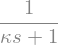

In [8]:
# The Laplace-transform identification: the initial data of Eqs. (9)-(10) of Balan (2023) ramp the plate on kappa
eps = sp.Symbol('epsilon', positive=True)
C1, C2 = sp.symbols('C_1 C_2')
A = -kappa/(1 + kappa*s)                       # strength of the delta' source
# homogeneous correction w: w(0) = 0 near the plate, decay far from it
w_inner = C1*sp.sinh(k*xi)
w_outer = C2*sp.exp(-k*xi)
jumps = [sp.Eq(w_outer.subs(xi, eps) - w_inner.subs(xi, eps), A),
         sp.Eq(sp.diff(w_outer, xi).subs(xi, eps) - sp.diff(w_inner, xi).subs(xi, eps), 0)]
solution = sp.solve(jumps, [C1, C2])
w_far = sp.limit(solution[C2], eps, 0)*sp.exp(-k*xi)
v_inconsistent = vbar_sym + w_far
sp.simplify(v_inconsistent/vbar_sym)

The ramped-plate solution is also exact. By [Duhamel's principle](https://en.wikipedia.org/wiki/Duhamel%27s_principle), the velocity for the plate velocity $U(t) = 1 - \mathrm{e}^{-t/\kappa}$ is $\int_0^t v_\mathrm{step}(\xi, t - t')\,U'(t')\,\mathrm{d}t'$, where $v_\mathrm{step}$ is the consistent start-up. In the half-space, the next cell evaluates this integral with `quad` on Eq. (7), with breakpoints where $U'$ has decayed and where the front (speed 1 at $\mathrm{Re} = 1$) passes $\xi$. In the gap, each mode of Eqs. (42)&ndash;(43) of Christov (2013) is a sum of two exponentials, so the convolution is done in closed form, mode by mode, which gives the ramped-plate series below.

In [9]:
# Exact ramped-plate solution in the half-space, Re = 1: Duhamel's principle on Eq. (7), by quad
def ramped_plate_halfspace(xi, t, kappa):
    """Exact solution for the plate velocity 1 - exp(-t/kappa), Re = 1, at one distance xi > 0 from the plate."""
    if t <= 0:
        return 0.0
    # v(xi, t) = int_0^t v_step(xi, t - s) U'(s) ds, with U'(s) = exp(-s/kappa)/kappa;
    # breakpoints where U' has decayed and where the front (speed 1) passes xi
    points = [p for p in [10*kappa, t - xi] if 0 < p < t]
    integrand = lambda s: halfspace_exact(xi, t - s, 1.0, kappa)*np.exp(-s/kappa)/kappa
    return quad(integrand, 0, t, points=points, limit=200)[0]

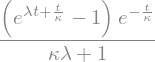

In [10]:
# Duhamel's principle for one exponential of a mode of Eq. (43): int_0^t exp(lambda (t - s)) U'(s) ds in closed form
t_sym, s_sym, lam_sym, kappa_sym = sp.symbols('t s lambda kappa', positive=True)
convolution = sp.integrate(sp.exp(lam_sym*(t_sym - s_sym))*sp.exp(-s_sym/kappa_sym)/kappa_sym, (s_sym, 0, t_sym), conds='none')
sp.simplify(convolution)

That is, $\big(\mathrm{e}^{\lambda t} - \mathrm{e}^{-t/\kappa}\big)/(1 + \kappa\lambda)$. Writing $\exp[-(1+\lambda_n\alpha)t/(2\tau)]A_n(t)$ of Eq. (43) as $c_1\mathrm{e}^{\lambda_1 t} + c_2\mathrm{e}^{\lambda_2 t}$, with $\lambda_{1,2} = [-(1+\lambda_n\alpha) \pm \sqrt{\Delta_n}]/(2\tau)$ and $c_{1,2} = \tfrac{1}{2}[1 \pm (1-\lambda_n\alpha)/\sqrt{\Delta_n}]$ (complex for $\Delta_n < 0$), the ramped-plate solution in the gap is
$$
    v(y,t) = (1 - y)\left(1 - \mathrm{e}^{-t/\kappa}\right) - \frac{2}{\pi}\sum_{n=1}^\infty \mathrm{Re}\left[\sum_{j=1}^{2} c_j\,\frac{\mathrm{e}^{\lambda_j t} - \mathrm{e}^{-t/\kappa}}{1 + \kappa\lambda_j}\right]\frac{\sin(n\pi y)}{n},
$$
with $y$ the distance from the plate. (For $\kappa = 1$, $\lambda_1 = -1/\kappa$ with $c_1 = 0$, a removable $0/0$; it is not used here.) The next cell implements it, then checks it against the Duhamel integral of Eqs. (42)&ndash;(43) by `quad` at three points.

In [11]:
# Exact ramped-plate solution in the gap: Duhamel's principle on Eqs. (42)-(43) of Christov (2013), mode by mode
def ramped_plate_gap(y, t, kappa, Re=1.0, nterms=200):
    """Exact solution in the gap for the plate velocity 1 - exp(-t/kappa); y is the distance from the plate."""
    tau = 1/Re
    alpha = kappa/Re
    v = (1 - y)*(1 - np.exp(-t/kappa))
    for n in range(1, nterms+1):
        lam = (n*np.pi)**2
        sD = np.sqrt(complex((1 + lam*alpha)**2 - 4*lam*tau))
        # exp(-(1 + lam alpha) t/(2 tau)) A_n(t) = c1 exp(l1 t) + c2 exp(l2 t), each exponential convolved in closed form
        l1 = (-(1 + lam*alpha) + sD)/(2*tau)
        l2 = (-(1 + lam*alpha) - sD)/(2*tau)
        c1 = 0.5*(1 + (1 - lam*alpha)/sD)
        c2 = 0.5*(1 - (1 - lam*alpha)/sD)
        mode = c1*(np.exp(l1*t) - np.exp(-t/kappa))/(1 + kappa*l1) + c2*(np.exp(l2*t) - np.exp(-t/kappa))/(1 + kappa*l2)
        v = v - 2/np.pi*mode.real*np.sin(n*np.pi*y)/n
    return v

# check: the Duhamel integral of Eqs. (42)-(43) by quad
def ramped_plate_gap_quad(y, t, kappa, Re=1.0, nterms=200):
    """The same by quad: int_0^t v_step(y, t - s) U'(s) ds, with U'(s) = exp(-s/kappa)/kappa."""
    integrand = lambda s: gap_exact(y, t - s, 1/Re, kappa/Re, nterms)*np.exp(-s/kappa)/kappa
    return quad(integrand, 0, t, limit=200)[0]

print('CLOSED-FORM RAMPED-PLATE SERIES VERSUS THE DUHAMEL INTEGRAL BY QUAD (200 terms each)')
for y, t, kappa_value in [(0.1, 0.3, 0.2), (0.5, 1.0, 0.05), (0.9, 2.0, 0.4)]:
    difference = abs(ramped_plate_gap(y, t, kappa_value) - ramped_plate_gap_quad(y, t, kappa_value))
    print(f'  y = {y}, t = {t}, kappa = {kappa_value}: {difference:.1e}')

CLOSED-FORM RAMPED-PLATE SERIES VERSUS THE DUHAMEL INTEGRAL BY QUAD (200 terms each)
  y = 0.1, t = 0.3, kappa = 0.2: 2.2e-16
  y = 0.5, t = 1.0, kappa = 0.05: 2.8e-15
  y = 0.9, t = 2.0, kappa = 0.4: 2.6e-11


The next cell compares the finite-difference solution for Balan's initial data (`inconsistent_ic=True`) with the exact ramped-plate solutions, for $\kappa = 0.05$, $0.2$, $0.4$: in the half-space ($L = 25$, $M = 5000$) at $\xi = 0.5$, $2$, $5$ for $0.5 \le t \le 10$, and in the gap ($L = 1$, $M = 800$) at distances $0.05 \le y \le 0.9$ from the plate for $0.05 \le t \le 3$. The differences should be at the level of the scheme's error, largest at small $\kappa$ and close to the plate, while the difference from the consistent start-up (also printed, for the half-space) should not.

In [12]:
# Balan's initial data (finite differences) versus the exact ramped-plate solutions, half-space and gap
print('HALF-SPACE: max|startup_fd, inconsistent_ic=True (L = 25, M = 5000) - Duhamel on Eq. (7)|, 0.5 <= t <= 10')
distances = np.array([0.5, 2.0, 5.0])
times = np.linspace(0.5, 10, 20)
L = 25.0
for kappa_value in [0.05, 0.2, 0.4]:
    exact = np.array([[ramped_plate_halfspace(d, t, kappa_value) for d in distances] for t in times])
    startup = np.array([[halfspace_exact(d, t, 1.0, kappa_value) for d in distances] for t in times])
    samples = inconsistent_balan_9_10(distances, times, kappa_value, L=L, M=5000)
    errors = np.abs(samples - exact).max(axis=0)
    print(f'  kappa = {kappa_value}: xi = 0.5: {errors[0]:.1e}, xi = 2: {errors[1]:.1e}, xi = 5: {errors[2]:.1e}; '
          f'versus the consistent start-up: {np.abs(samples - startup).max():.2f}')

print('\nGAP: max|startup_fd, inconsistent_ic=True (L = 1, M = 800) - closed-form ramped-plate series|, 0.05 <= t <= 3')
y = np.array([0.05, 0.1, 0.25, 0.5, 0.75, 0.9])   # distance from the plate
times = np.linspace(0.05, 3, 60)
for kappa_value in [0.05, 0.2, 0.4]:
    exact = np.array([ramped_plate_gap(y, t, kappa_value, nterms=2000) for t in times])
    samples = inconsistent_balan_9_10(y, times, kappa_value, L=1.0, M=800)
    print(f'  kappa = {kappa_value}: {np.abs(samples - exact).max():.1e}')

HALF-SPACE: max|startup_fd, inconsistent_ic=True (L = 25, M = 5000) - Duhamel on Eq. (7)|, 0.5 <= t <= 10


  kappa = 0.05: xi = 0.5: 5.3e-05, xi = 2: 1.3e-05, xi = 5: 1.6e-06; versus the consistent start-up: 0.10


  kappa = 0.2: xi = 0.5: 4.0e-06, xi = 2: 1.6e-06, xi = 5: 3.8e-07; versus the consistent start-up: 0.20


  kappa = 0.4: xi = 0.5: 7.9e-07, xi = 2: 7.7e-07, xi = 5: 2.0e-07; versus the consistent start-up: 0.29

GAP: max|startup_fd, inconsistent_ic=True (L = 1, M = 800) - closed-form ramped-plate series|, 0.05 <= t <= 3


  kappa = 0.05: 7.1e-06


  kappa = 0.2: 1.3e-06


  kappa = 0.4: 5.5e-07


# AN INDEPENDENT CHECK

The next cell checks `startup_fd` with consistent initial data against the de Hoog inversion (these are independent: one is finite differences, the other the exact transform), and prints its convergence as the grid is refined, at distances $\xi \ge 0.5$ from the plate, where it should be second order.

Where a convergence table prints a number in parentheses, it is the estimated order of convergence, $\log_2$ of the ratio of successive errors.

In [13]:
# startup_fd with consistent data versus de Hoog, kappa = 0.2, Re = 1
distances = np.array([0.5, 2.0, 5.0])
times = np.linspace(0.25, 10, 40)
L = 20.0
exact = dehoog_inverse(distances, times, 0.2)
print('CONVERGENCE OF THE SCHEME versus de Hoog, xi = 0.5, 2, 5')
print('  grid: max error (estimated order of convergence)')
# the estimated order of convergence is log2 of the ratio of successive errors, since the grid is halved
previous = None
for M in [500, 1000, 2000, 4000]:
    x, v, samples = startup_fd(M=M, a=1.0, kappa=0.2, Re=1.0, tmax=times[-1], L=L, sample_t=times, sample_x=L - distances)
    error = np.abs(samples - exact).max()
    if previous is None:
        print(f'  M = {M:4d}: {error:.1e}')
    else:
        print(f'  M = {M:4d}: {error:.1e} ({np.log2(previous/error):.2f})')
    previous = error

CONVERGENCE OF THE SCHEME versus de Hoog, xi = 0.5, 2, 5
  grid: max error (estimated order of convergence)
  M =  500: 2.2e-03
  M = 1000: 8.5e-04 (1.35)


  M = 2000: 2.2e-04 (1.96)


  M = 4000: 5.5e-05 (1.99)


# THE PAPER'S FIGURES

These are the velocity panels of Fig. 3(a) and (b) of Balan (2023): $v$ versus $t$ at distances $\xi = 8$, $5$, $3.5$, $2$, $1$, $0.5$ from the moving plate ($x = 92, \dots, 99.5$ for $x_0 = 100$), $\mathrm{Re} = 1$, Oldroyd-B, (a) $\kappa = 0.2$ and (b) $\kappa = 0.001$. Curves are exact: the consistent start-up, Eq. (7) of C. I. Christov & P. M. Jordan (2009) (solid), and the ramped plate (dashed). Symbols are numerical: `startup_fd` with Balan's initial data, $M = 4000$ (open circles).

For $\kappa = 0.001$ the ramped plate differs from the consistent start-up by less than $10^{-4}$, so only the solid curves are drawn; there Eq. (7) is evaluated from $t = 0.5$ on, since far ahead of the front ($t < 0.4$ at $\xi = 8$) its quadrature does not converge, where $v < 10^{-9}$ by de Hoog's inversion.

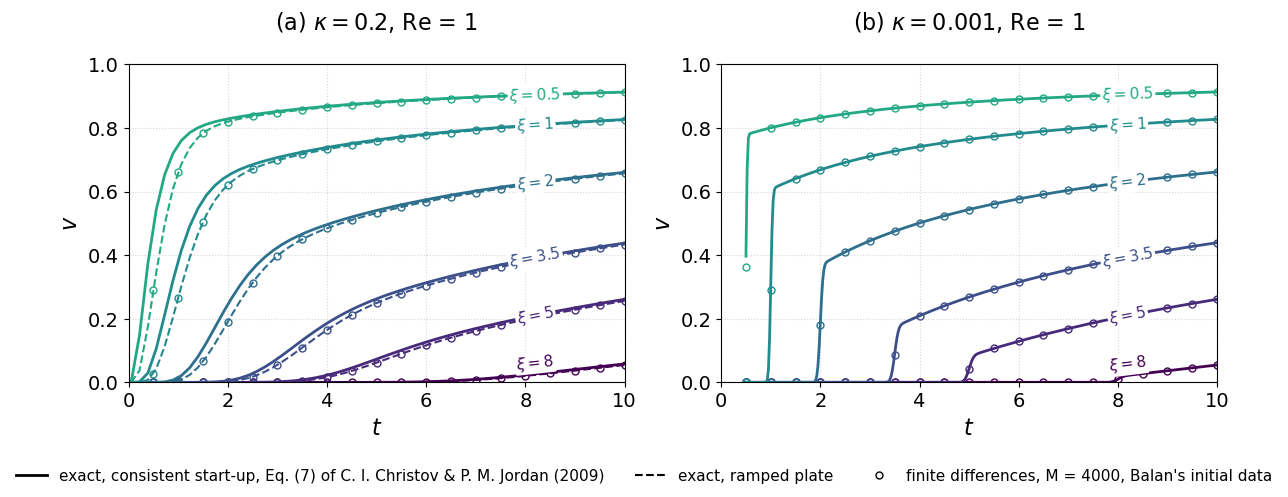

In [14]:
# Fig. 3(a)-(b) of Balan (2023), velocity: exact solutions (curves) and Balan's initial data by finite differences (symbols)
def label_on_curve(ax, x_curve, y_curve, x_label, text, color):
    """Write text on the curve at x_label, rotated along it, on a white background."""
    y_label = np.interp(x_label, x_curve, y_curve)
    y_ahead = np.interp(x_label + 0.3, x_curve, y_curve)
    # the slope in screen coordinates, so that the text follows the curve as drawn
    p0 = ax.transData.transform((x_label, y_label))
    p1 = ax.transData.transform((x_label + 0.3, y_ahead))
    angle = np.degrees(np.arctan2(p1[1] - p0[1], p1[0] - p0[0]))
    if y_label < 0.05:
        y_label = y_label + 0.035   # a curve hugging the axis: put the label just above it
    ax.text(x_label, y_label, text, color=color, fontsize=11, rotation=angle, rotation_mode='anchor',
            ha='center', va='center', bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='none'))

distances = np.array([8.0, 5.0, 3.5, 2.0, 1.0, 0.5])
times_symbols = np.arange(0.5, 10.1, 0.5)   # sparse, so that the curves stay visible
cmap = colormaps['viridis']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
curves = []
curve_times = []
for k, kappa_value in enumerate([0.2, 0.001]):
    ax = axes[k]
    if kappa_value == 0.2:
        times = np.linspace(0.05, 10, 60)
    else:
        times = np.linspace(0.5, 10, 400)   # fine, to resolve the fronts; Eq. (7) starts at t = 0.5 (see above)
    v_step = np.array([[halfspace_exact(d, t, 1.0, kappa_value) for d in distances] for t in times])
    v_balan = inconsistent_balan_9_10(distances, times_symbols, kappa_value, M=4000)
    curves.append(v_step)
    curve_times.append(times)
    for j in range(len(distances)):
        color = cmap(0.6*j/(len(distances) - 1))
        ax.plot(times, v_step[:, j], color=color, linewidth=2)
        if kappa_value == 0.2:
            v_ramp = [ramped_plate_dehoog(distances[j], t, kappa_value) for t in times]
            ax.plot(times, v_ramp, color=color, linewidth=1.5, linestyle='dashed')
        ax.plot(times_symbols, v_balan[:, j], 'o', color=color, markerfacecolor='none', markersize=5)
    ax.plot([], [], color='black', linewidth=2, label='exact, consistent start-up, Eq. (7) of C. I. Christov & P. M. Jordan (2009)')
    if kappa_value == 0.2:
        ax.plot([], [], color='black', linewidth=1.5, linestyle='dashed', label='exact, ramped plate')
    ax.plot([], [], 'o', color='black', markerfacecolor='none', markersize=5,
            label="finite differences, M = 4000, Balan's initial data")
    ax.set_xlabel('$t$')
    ax.set_ylabel('$v$')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1)
    ax.set_title(f'({"ab"[k]}) ' + rf'$\kappa = {kappa_value:g}$, Re = 1')
    ax.grid(alpha=0.5, linestyle='dotted')
# one legend below both panels, so that it hides no curve
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=11, frameon=False)
# fix the layout first, so that the label angles computed in screen coordinates stay correct
fig.tight_layout(rect=(0, 0.08, 1, 1))
for k in range(2):
    for j in range(len(distances)):
        color = cmap(0.6*j/(len(distances) - 1))
        label_on_curve(axes[k], curve_times[k], curves[k][:, j], 8.2, rf'$\xi = {distances[j]:g}$', color)
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/balan_2023_fig3ab.png', dpi=200, bbox_inches='tight')

The dashed curves, and the open circles computed from Balan's initial data, lag the solid ones because his data start the plate as $1 - \mathrm{e}^{-t/\kappa}$ rather than at once. The lag is set by the dimensionless retardation time $\kappa = \lambda_2/\lambda_1$ and fades after a few $\kappa$, which is why the two solutions agree at long times. It vanishes for a Maxwell fluid ($\kappa = 0$), which has no solvent stress to be set wrongly at $t = 0$.

# EXPLORE IT YOURSELF

The left panel is the velocity profile at the slider's time; the right is the history of the shear stress at a fixed distance $\xi = 0.5$ from the plate, as in Fig. 3(a) of Balan (2023), with the slider's time marked. The $\delta$ that Balan's initial data put into the polymer stress lives at $t = 0$ alone, so it is never on screen; what the stress panel shows is its consequence, the near-wall peak arriving later and lower.

In [15]:
# Exact solutions (curves) and Balan's initial data by finite differences (symbols): plot function
def plot_func(kappa, t):
    L = 20.0
    xi_probe = 0.5   # the distance from the plate at which the stress history is drawn
    xi = np.linspace(0, 8, 60)
    xi_ramp = np.linspace(0, 8, 25)   # the ramped plate is smooth, so fewer points are needed
    xi_symbols = np.linspace(0.25, 8, 16)   # sparse, so that the curves stay visible
    xi_arrows = np.linspace(0, 8, 16)   # about 15 arrows, one at the plate
    # denser before t = 2, where the stress peaks; every point is a de Hoog inversion
    t_history = np.concatenate([np.linspace(0.2, 2, 14), np.linspace(2.5, 8, 8)])
    v_step = np.array([halfspace_exact(d, t, 1.0, kappa) for d in xi])
    v_ramp = np.array([ramped_plate_dehoog(d, t, kappa) if d > 0 else 1 - np.exp(-t/kappa) for d in xi_ramp])
    sigma_step = sigma_history(xi_probe, t_history, kappa)
    sigma_ramp = sigma_history(xi_probe, t_history, kappa, ramp=True)
    # one finite-difference run gives both the profile at the slider's time and the stress history at xi_probe
    sample_t = np.sort(np.append(t_history, t))
    sigma_balan = []
    v_balan = inconsistent_balan_9_10(np.append(xi_symbols, xi_probe), sample_t, kappa, L=L, sample_sigma=sigma_balan)
    now = int(np.argmin(np.abs(sample_t - t)))

    fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), tight_layout=True)
    ax[0].set_ylabel(r'$\xi$')
    ax[0].set_ylim(0, 8)
    ax[0].set_xlabel('$v$')
    ax[0].set_xlim(0, 1.1)
    ax[0].plot(v_step, xi, color='darkblue', linewidth=4, zorder=4, label=f'exact, consistent start-up, $t={t:.2f}$')
    ax[0].quiver(0*xi_arrows, xi_arrows, np.interp(xi_arrows, xi, v_step), 0*xi_arrows,
                 scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
    ax[0].plot(v_ramp, xi_ramp, color='#D55E00', linewidth=2, linestyle='dashed', zorder=4, label='exact, ramped plate')
    ax[0].plot(v_balan[now][:-1], xi_symbols, 'o', color='#D55E00', markerfacecolor='none', zorder=4,
               label="finite differences, Balan's initial data")
    ax[0].legend(loc='upper right')
    ax[0].grid(alpha=0.5, linestyle='dotted')

    ax[1].set_xlabel('$t$')
    ax[1].set_ylabel(rf'$\sigma(\xi = {xi_probe:g}, t)$')
    ax[1].set_xlim(0, 8)
    ax[1].set_ylim(0, max(0.7, 1.05*sigma_step.max()))
    ax[1].yaxis.set_label_position('right')
    ax[1].yaxis.set_ticks_position('right')
    ax[1].plot(t_history, sigma_step, color='darkblue', linewidth=3, zorder=4)
    ax[1].plot(t_history, sigma_ramp, color='#D55E00', linewidth=2, linestyle='dashed', zorder=4)
    ax[1].plot(sample_t, np.array(sigma_balan)[:, -1], 'o', color='#D55E00', markerfacecolor='none', zorder=4)
    ax[1].axvline(t, color='gray', linewidth=1)
    ax[1].plot(t, np.interp(t, t_history, sigma_step), 'o', color='darkblue', zorder=5)
    ax[1].grid(alpha=0.5, linestyle='dotted')
    plt.show()

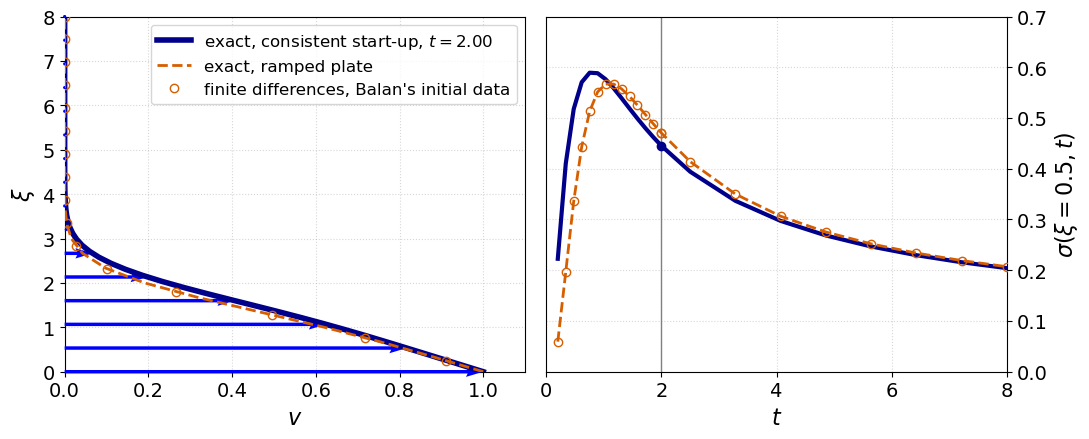

In [16]:
# Exact solutions and Balan's initial data: static plot (the interactive widget below is stripped in the GitHub preview)
plot_func(0.2, 2.0)

In [17]:
# Exact solutions and Balan's initial data: interactive plot (kappa >= 0.05 keeps the Duhamel integral fast)
interact(plot_func,
         kappa=widgets.FloatSlider(value=0.2, min=0.05, max=0.9, step=0.01, description='Ratio, κ'),
         t=widgets.FloatSlider(value=2.0, min=0.1, max=8, step=0.1, description='Time, t'));

In [18]:
# Exact solutions (curves) and Balan's initial data by finite differences (symbols): animation, sampled once
kappa_value = 0.2
L = 20.0
numframes = 25
tmax = 8.0
# the frame time steps as the square of the counter, so that the front, which spreads like
# sqrt(t), advances evenly and the early times, where the ramp is, are not stepped over
frame_times = ((np.arange(numframes) + 1)/numframes)**2*tmax
xi = np.linspace(0, 8, 50)
xi_ramp = np.linspace(0, 8, 17)   # the Duhamel integral is slower, and the ramped plate is smooth
xi_sigma = np.linspace(0, 8, 15)   # coarse: every point is a de Hoog inversion
xi_symbols = np.linspace(0.25, 8, 16)   # sparse, so that the curves stay visible
xi_arrows = np.linspace(0, 8, 16)   # about 15 arrows, one at the plate
frames_step = np.array([[halfspace_exact(d, t, 1.0, kappa_value) for d in xi] for t in frame_times])
frames_ramp = np.array([[ramped_plate_dehoog(d, t, kappa_value) if d > 0 else 1 - np.exp(-t/kappa_value) for d in xi_ramp]
                        for t in frame_times])
frames_sigma_step = np.array([dehoog_sigma(xi_sigma, t, kappa_value) for t in frame_times])
frames_sigma_ramp = np.array([dehoog_sigma(xi_sigma, t, kappa_value, ramp=True) for t in frame_times])
sigma_balan = []
frames_balan = inconsistent_balan_9_10(xi_symbols, frame_times, kappa_value, L=L, M=2000, sample_sigma=sigma_balan)
frames_sigma_balan = np.array(sigma_balan)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), tight_layout=True)
ax[0].set_ylabel(r'$\xi$')
ax[0].set_ylim(0, 8)
ax[0].set_xlabel('$v$')
ax[0].set_xlim(0, 1.1)
ax[0].grid(alpha=0.5, linestyle='dotted')
ax[1].set_ylabel(r'$\xi$')
ax[1].set_ylim(0, 8)
ax[1].set_xlabel(r'$\sigma$')
ax[1].set_xlim(0, 0.9)
ax[1].yaxis.set_label_position('right')
ax[1].yaxis.set_ticks_position('right')
ax[1].grid(alpha=0.5, linestyle='dotted')
plt.close()

line, = ax[0].plot(frames_step[0], xi, color='darkblue', linewidth=4, zorder=4, label='exact, consistent start-up')
line_ramp, = ax[0].plot(frames_ramp[0], xi_ramp, color='#D55E00', linewidth=2, linestyle='dashed', zorder=4, label='exact, ramped plate')
dots, = ax[0].plot(frames_balan[0], xi_symbols, 'o', color='#D55E00', markerfacecolor='none', zorder=4, label="finite differences, Balan's initial data")
quiv = ax[0].quiver(0*xi_arrows, xi_arrows, np.interp(xi_arrows, xi, frames_step[0]), 0*xi_arrows,
                    scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
line_s, = ax[1].plot(frames_sigma_step[0], xi_sigma, color='darkblue', linewidth=4, zorder=4)
line_s_ramp, = ax[1].plot(frames_sigma_ramp[0], xi_sigma, color='#D55E00', linewidth=2, linestyle='dashed', zorder=4)
dots_s, = ax[1].plot(frames_sigma_balan[0], xi_symbols, 'o', color='#D55E00', markerfacecolor='none', zorder=4)
ax[0].legend(loc='upper right')

# animation function called sequentially by `FuncAnimation' below
def animate(i):
    line.set_data(frames_step[i], xi)
    line_ramp.set_data(frames_ramp[i], xi_ramp)
    dots.set_data(frames_balan[i], xi_symbols)
    quiv.set_UVC(np.interp(xi_arrows, xi, frames_step[i]), 0*xi_arrows)
    line_s.set_data(frames_sigma_step[i], xi_sigma)
    line_s_ramp.set_data(frames_sigma_ramp[i], xi_sigma)
    dots_s.set_data(frames_sigma_balan[i], xi_symbols)
    line.set_label(f'exact, consistent start-up, $t={frame_times[i]:.3g}$')
    legend = ax[0].legend(loc='upper right')
    return (line, line_ramp, dots, quiv, line_s, line_s_ramp, dots_s, legend)

anim = animation.FuncAnimation(fig, animate, frames=numframes, interval=300, blit=True, repeat=False)

In [19]:
# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
anim

In [20]:
# To save the animation, use something like
# anim.save('balan_2023_startup_couette.mp4')

# FIGURE 1 OF THE COMMENT

This is Fig. 1 of I. C. Christov, Comment on &ldquo;Note on the start-up of Couette flow for viscoelastic fluids&rdquo; [Phys. Fluids 35, 113108 (2023)] (submitted).

Panels (a) and (b) are the large gap of Balan's Figs. 3 and 4, with the moving plate at $x_0 = 100$, and panel (c) is the unit gap of his Figs. 7&ndash;9, with the plate at $x = 1$; distances are given in his $x$ throughout, rather than in the distance $\xi = x_0 - x$ from the plate used elsewhere in this notebook.

(a) $v(x = 95, t)$, that is, $\xi = 5$, for $a = 1$, $\mathrm{Re} = 1$, $\kappa = 0.4$ and $0.2$. Curves are exact: the consistent start-up, Eq. (7) of C. I. Christov & P. M. Jordan (2009) (solid), and the ramped plate (dashed). Symbols are numerical: `startup_fd` with Balan's initial data, $L = 25$, $M = 5000$ (open), and the values read from his figures (filled), for $\kappa = 0.4$ from Fig. 4(a) and for $\kappa = 0.2$ from Fig. 3(a).

(b) The shear stress $\sigma(x = 99.5, t)$ of Fig. 3(a), at the same two $\kappa$ and in the same colors, where the peak of Balan's initial data is both lower and later. The crosses are read from the shear-stress panel of his Fig. 3(a), which gives the stress for $\kappa = 0.2$ only.

(c) The normal stress at the wall, $N(x = 1, t)$, for $a = 0$, $\kappa = 0.01$, $\mathrm{Re} = 1$, $N_0 = 0$, by `startup_fd` in the gap $0\le x\le 1$, on a logarithmic time axis: consistent start-up (solid, $M = 400$) and Balan's initial data on $M = 100$, $200$, $400$ cells (dashed). The cell also prints the minimum of $N(x = 1, t)$ for each grid. The figure is one journal page (7 in) wide, in a journal style (serif fonts, 8 pt). Its legends use the wording of the Comment's caption: Tanner's problem for the consistent start-up, IBVP (9)&ndash;(10) for Balan's initial data.

MINIMUM OF N(1, t), a = 0, kappa = 0.01, Re = 1, N0 = 0, 0 < t <= 20


  consistent start-up, M = 400: 0.09


  IBVP (9)-(10), M = 100: -0.85


  IBVP (9)-(10), M = 200: -2.53


  IBVP (9)-(10), M = 400: -6.38


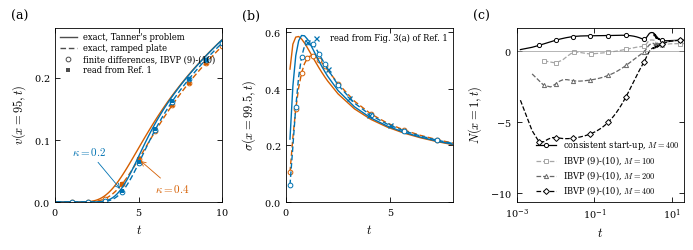

In [21]:
# Fig. 1 of the Comment, one journal page wide: (a) v(x = 95, t); (b) sigma(xi = 0.5, t); (c) N(1, t)
# values read from Fig. 4(a) of Balan (2023), columns kappa, t, v: calibrated on the tick labels,
# at the integer t free of the annotations (the blue t_c markers and the labels)
digitized = np.array([[1.0, 5, 0.1139], [1.0, 6, 0.1491], [1.0, 8, 0.2115], [1.0, 9, 0.2389],
                      [0.4, 4, 0.0286], [0.4, 5, 0.0690], [0.4, 6, 0.1141], [0.4, 7, 0.1555],
                      [0.4, 8, 0.1917], [0.4, 9, 0.2233]])
# values read from Fig. 3(a) of Balan (2023), kappa = 0.2, Re = 1: columns xi, t, v
read_3a = np.array([[0.5, 2, 0.8209], [0.5, 3, 0.8482], [0.5, 4, 0.8653], [0.5, 5, 0.8782], [0.5, 6, 0.8880], [0.5, 7, 0.8952],
                    [0.5, 8, 0.9019], [0.5, 9, 0.9076], [1.0, 2, 0.6242], [1.0, 4, 0.7336], [1.0, 5, 0.7584], [1.0, 6, 0.7780],
                    [1.0, 7, 0.7930], [1.0, 8, 0.8054], [1.0, 9, 0.8162], [2.0, 2, 0.1977], [2.0, 3, 0.4006], [2.0, 4, 0.4858],
                    [2.0, 5, 0.5333], [2.0, 6, 0.5689], [2.0, 7, 0.5973], [2.0, 8, 0.6205], [2.0, 9, 0.6407], [3.5, 3, 0.0578],
                    [3.5, 4, 0.1673], [3.5, 5, 0.2514], [3.5, 6, 0.3046], [3.5, 7, 0.3464], [3.5, 8, 0.3795], [3.5, 9, 0.4089],
                    [5.0, 4, 0.0176], [5.0, 5, 0.0640], [5.0, 6, 0.1177], [5.0, 7, 0.1621], [5.0, 8, 0.1982], [5.0, 9, 0.2292],
                    [8.0, 8, 0.0207], [8.0, 9, 0.0377]])
# the same, read from the kappa = 0.2 panel of Fig. 4(a) (its second row), columns t, v
read_4a_02 = np.array([[3, 0.0054], [7, 0.1555], [7.5, 0.1742], [8, 0.1914], [8.5, 0.2079], [9, 0.2232]])
# values read from the shear-stress panel of Fig. 3(a), kappa = 0.2, at x = 99.5 (xi = 0.5): columns t, sigma
# (the curve merges with its neighbor after t = 5, so the later times are not readable)
read_3a_sigma = np.array([[1, 0.5659], [2, 0.4695], [3, 0.3696], [4, 0.3093], [5, 0.2707]])
# kappa = 0.2 is read from Fig. 3(a), not from the kappa = 0.2 panel of Fig. 4(a): that panel repeats the
# kappa = 0.4 curve, agreeing with the kappa = 0.4 ramped plate to 3e-4 and missing the kappa = 0.2 one by 6e-3,
# while the values of Fig. 3(a) follow the kappa = 0.2 ramped plate (the checks below print both differences)
xi_probe = 5.0     # x = 95, with the plate at x_0 = 100 in Balan's units
xi_stress = 0.5    # the near-wall station of Fig. 3(a), where the shear stress peaks
L = 25.0
times = np.linspace(0.05, 10, 80)
times_symbols = np.arange(1.0, 10.1, 1.0)   # sparse, so that the curves stay visible
t_stress = np.concatenate([np.linspace(0.2, 2, 14), np.linspace(2.5, 8, 8)])   # denser where sigma peaks
colors = {0.4: '#D55E00', 0.2: '#0072B2'}   # vermillion and blue, distinguishable in color and in grayscale

# a journal style: Computer Modern to match the text of the Comment, 8 pt, ticks inside on all four sides
journal = {'font.family': 'serif', 'font.serif': ['cmr10', 'DejaVu Serif'], 'mathtext.fontset': 'cm',
           'axes.unicode_minus': False, 'axes.formatter.use_mathtext': True, 'font.size': 8,
           'axes.labelsize': 9, 'xtick.labelsize': 7, 'ytick.labelsize': 7, 'legend.fontsize': 6,
           'axes.linewidth': 0.6, 'xtick.major.width': 0.6, 'ytick.major.width': 0.6,
           'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.top': True, 'ytick.right': True}
with plt.rc_context(journal):
    fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.35))

    # (a) velocity five elastic lengths from the plate, for the two viscoelastic cases of Ref. 1
    ax = axes[0]
    for kappa_value, read in [(0.4, digitized[digitized[:, 0] == 0.4][:, 1:]),
                              (0.2, read_3a[read_3a[:, 0] == xi_probe][:, 1:])]:
        color = colors[kappa_value]
        v_step = [halfspace_exact(xi_probe, t, 1.0, kappa_value) for t in times]
        v_ramp = [ramped_plate_dehoog(xi_probe, t, kappa_value) for t in times]
        v_balan = inconsistent_balan_9_10(np.array([xi_probe]), times_symbols, kappa_value, L=L, M=5000)[:, 0]
        ax.plot(times, v_step, color=color, linewidth=1.0)
        ax.plot(times, v_ramp, color=color, linewidth=1.0, linestyle=(0, (4, 2)))
        ax.plot(times_symbols, v_balan, 'o', color=color, markerfacecolor='white', markersize=3.4, markeredgewidth=0.7)
        ax.plot(read[:, 0], read[:, 1], 's', color=color, markersize=2.6, markeredgewidth=0)
    ax.annotate(r'$\kappa = 0.4$', xy=(5.0, 0.069), xytext=(6.0, 0.015), color=colors[0.4],
                arrowprops=dict(arrowstyle='->', lw=0.6, color=colors[0.4], shrinkB=2))
    ax.annotate(r'$\kappa = 0.2$', xy=(4.0, 0.018), xytext=(1.0, 0.075), color=colors[0.2],
                arrowprops=dict(arrowstyle='->', lw=0.6, color=colors[0.2], shrinkB=2))
    # the legend names the sources in the wording of the Comment's caption
    ax.plot([], [], color='0.3', linewidth=1.0, label="exact, Tanner's problem")
    ax.plot([], [], color='0.3', linewidth=1.0, linestyle=(0, (4, 2)), label='exact, ramped plate')
    ax.plot([], [], 'o', color='0.3', markerfacecolor='white', markersize=3.4, markeredgewidth=0.7,
            label='finite differences, IBVP (9)-(10)')
    ax.plot([], [], 's', color='0.3', markersize=2.6, markeredgewidth=0, label='read from Ref. 1')
    ax.legend(loc='upper left', frameon=False, handlelength=2.0, borderaxespad=0.2, labelspacing=0.25)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 0.28)
    ax.set_xlabel('$t$')
    ax.set_ylabel(r'$v(x = 95, t)$')

    # (b) the near-wall shear stress of Fig. 3(a), at x = 99.5 (xi = 0.5): the peak of IBVP (9)-(10)
    # is lower and later
    ax = axes[1]
    for kappa_value in [0.4, 0.2]:
        color = colors[kappa_value]
        sigma_balan = []
        inconsistent_balan_9_10(np.array([xi_stress]), t_stress[::2], kappa_value, L=L, M=5000,
                                sample_sigma=sigma_balan)
        ax.plot(t_stress, sigma_history(xi_stress, t_stress, kappa_value), color=color, linewidth=1.0)
        ax.plot(t_stress, sigma_history(xi_stress, t_stress, kappa_value, ramp=True), color=color,
                linewidth=1.0, linestyle=(0, (4, 2)))
        ax.plot(t_stress[::2], np.array(sigma_balan)[:, 0], 'o', color=color, markerfacecolor='white',
                markersize=3.4, markeredgewidth=0.7)
    # Fig. 3(a) gives the stress only for kappa = 0.2, so the crosses are on the blue curves alone
    ax.plot(read_3a_sigma[:, 0], read_3a_sigma[:, 1], 'x', color=colors[0.2], markersize=3.6,
            markeredgewidth=0.9, label='read from Fig. 3(a) of Ref. 1')
    ax.legend(loc='upper right', frameon=False, handlelength=1.6, borderaxespad=0.3)
    ax.set_xlim(0, 8)
    ax.set_ylim(0, None)
    ax.set_xlabel('$t$')
    ax.set_ylabel(r'$\sigma(x = 99.5, t)$')

    # (c) normal stress at the wall, corotational model, on a logarithmic time axis (the dip lasts about one time step)
    ax = axes[2]
    print('MINIMUM OF N(1, t), a = 0, kappa = 0.01, Re = 1, N0 = 0, 0 < t <= 20')
    runs = [(400, False, '-', 'o', 'black'), (100, True, '--', 's', '0.65'), (200, True, '--', '^', '0.4'), (400, True, '--', 'D', 'black')]
    for M, inconsistent, line_style, marker, color in runs:
        wall = []
        startup_fd(M=M, a=0.0, kappa=0.01, Re=1.0, tmax=20.0, L=1.0, inconsistent_ic=inconsistent, wall_N=wall)
        t_wall = np.linspace(20.0/len(wall), 20.0, len(wall))
        marks = list(np.unique(np.searchsorted(t_wall, np.logspace(-2.5, 1.2, 9))))   # evenly spaced on the log axis
        if inconsistent:
            label = f'IBVP (9)-(10), $M = {M}$'
        else:
            label = f'consistent start-up, $M = {M}$'
        ax.plot(t_wall, wall, color=color, linewidth=0.9, linestyle=line_style, marker=marker, markevery=marks,
                markersize=3.0, markerfacecolor='white', markeredgewidth=0.7, label=label)
        print(f'  {label.replace("$", "")}: {min(wall):.2f}')
    ax.axhline(0, color='0.6', linewidth=0.5)
    ax.set_xscale('log')
    ax.set_xlim(1e-3, 20)
    ax.set_ylim(-10.6, 1.6)   # room below the curves for the legend
    ax.legend(loc='lower right', frameon=False, handlelength=2.4, borderaxespad=0.2, labelspacing=0.25)
    ax.set_xlabel('$t$')
    ax.set_ylabel('$N(x = 1, t)$')

    fig.tight_layout(w_pad=1.2)
    for ax, letter in zip(axes, ['(a)', '(b)', '(c)']):
        ax.text(-0.26, 1.03, letter, transform=ax.transAxes, ha='left', va='bottom',
                fontsize=plt.rcParams['axes.labelsize'])
    os.makedirs('../figures', exist_ok=True)
    fig.savefig('../figures/balan_2023_comment_fig1.pdf', bbox_inches='tight')
    fig.savefig('../figures/balan_2023_comment_fig1.png', dpi=300, bbox_inches='tight')
plt.show()

# NUMBERS QUOTED IN THE COMMENT

The next cell prints the remaining numbers of the Comment that are not in the checks above: the near-wall shear-stress peak of Fig. 3(a) of Balan (2023) ($\xi = 0.5$, $\kappa = 0.2$), for the consistent start-up and for the ramped plate, from the Laplace transform of $\sigma = [(1+\kappa s)/(1+s)]\,\partial v/\partial x$ inverted by de Hoog's algorithm; the maximum of the first stable branch of the steady flow curve for $a = 0$, $\sigma = \kappa\dot\gamma + (1-\kappa)\dot\gamma/(1+\dot\gamma^2)$, at $\kappa = 0.01$; and the steady wall shear stress $\sigma_0$ for $a = 0$, $\kappa = 0.01$, $\mathrm{Re} = 1$ with Balan's initial data, with the total variation of $\sigma(1,t)$ over $1 < t < 10$ as a measure of its oscillations, as the grid is refined from $100$ to $3200$ cells.

In [22]:
# Numbers quoted in the Comment
print('NEAR-WALL SHEAR-STRESS PEAK, xi = 0.5, kappa = 0.2, Re = 1 (de Hoog)')
peak_times = np.linspace(0.3, 2.5, 221)
peaks = []
for ramp in [False, True]:
    sigma = [float(mp.invertlaplace(lambda s: sigma_bar_mp(s, 0.5, 0.2, ramp), t, method='dehoog')) for t in peak_times]
    i = int(np.argmax(sigma))
    peaks.append((sigma[i], peak_times[i]))
    print(f'  {"ramped plate       " if ramp else "consistent start-up"}: max sigma = {sigma[i]:.4f} at t = {peak_times[i]:.2f}')
print(f'  ramped plate versus consistent start-up: {100*(1 - peaks[1][0]/peaks[0][0]):.1f}% lower, {peaks[1][1] - peaks[0][1]:.2f} later')

kappa_value = 0.01
slope = lambda g: kappa_value + (1 - kappa_value)*(1 - g**2)/(1 + g**2)**2
print(f'\nMAXIMUM OF THE FIRST STABLE BRANCH, a = 0, kappa = 0.01: lambda_1 gamma_dot = {brentq(slope, 0.5, 3.0):.3f}')

print('\nSTEADY WALL SHEAR STRESS, a = 0, kappa = 0.01, Re = 1, N0 = 0, Balan\'s initial data, t = 20')
for M in [100, 200, 400, 800, 1600, 3200]:
    wall = []
    startup_fd(M=M, a=0.0, kappa=0.01, Re=1.0, tmax=20.0, L=1.0, inconsistent_ic=True, wall_sigma=wall)
    t_wall = np.linspace(20.0/len(wall), 20.0, len(wall))
    window = (t_wall > 1) & (t_wall < 10)
    variation = np.abs(np.diff(np.array(wall)[window])).sum()
    print(f'  M = {M:4d}: sigma_0 = {wall[-1]:.4f}, total variation of sigma(1, t) over 1 < t < 10 = {variation:.2f}')

NEAR-WALL SHEAR-STRESS PEAK, xi = 0.5, kappa = 0.2, Re = 1 (de Hoog)


  consistent start-up: max sigma = 0.5906 at t = 0.81


  ramped plate       : max sigma = 0.5684 at t = 1.10
  ramped plate versus consistent start-up: 3.8% lower, 0.29 later

MAXIMUM OF THE FIRST STABLE BRANCH, a = 0, kappa = 0.01: lambda_1 gamma_dot = 1.021

STEADY WALL SHEAR STRESS, a = 0, kappa = 0.01, Re = 1, N0 = 0, Balan's initial data, t = 20


  M =  100: sigma_0 = 0.4393, total variation of sigma(1, t) over 1 < t < 10 = 3.52


  M =  200: sigma_0 = 0.4865, total variation of sigma(1, t) over 1 < t < 10 = 2.64


  M =  400: sigma_0 = 0.4865, total variation of sigma(1, t) over 1 < t < 10 = 2.24


  M =  800: sigma_0 = 0.4767, total variation of sigma(1, t) over 1 < t < 10 = 1.86


  M = 1600: sigma_0 = 0.4818, total variation of sigma(1, t) over 1 < t < 10 = 1.09


  M = 3200: sigma_0 = 0.4818, total variation of sigma(1, t) over 1 < t < 10 = 0.93


The next cell prints the rest: how far the ramped plate is from Tanner's solution at $x = 95$; how much Balan's initial data change the transient for $\kappa = 0.01$, for $a = 1$ and, on three grids including his, for $a = 0$; and the values read from his Fig. 3(a) ($\kappa = 0.2$) and from the Newtonian velocity profile at $t = 10$ of his Fig. 2, against the exact solutions (read as for Fig. 4(a); in Fig. 3(a) the points hidden by the annotation circle, and those where two curves merge near $v = 0$, are left out).

In [23]:
# More numbers quoted in the Comment
print("TANNER'S SOLUTION MINUS THE RAMPED PLATE AT x = 95 (xi = 5), kappa = 0.4")
for t in [4, 5, 6, 7, 8, 9]:
    step = halfspace_exact(5.0, t, 1.0, 0.4)
    ramp = ramped_plate_halfspace(5.0, t, 0.4)
    print(f'  t = {t}: {step - ramp:.4f}, {100*(step - ramp)/step:.0f}% of Tanner\'s value')

print("\nEFFECT OF BALAN'S INITIAL DATA FOR kappa = 0.01, Re = 1, N0 = 0 (gap 0 <= x <= 1, 0 < t <= 10)")
print('  a    M    max|v, Balan - v, consistent|   max|wall sigma, Balan - consistent|, t > 0.5')
times = np.linspace(0.05, 10, 200)
for a_value, M in [(1.0, 800), (0.0, 400), (0.0, 1000), (0.0, 1600)]:
    wall_consistent = []
    wall_balan = []
    x, v, v_consistent = startup_fd(M=M, a=a_value, kappa=0.01, Re=1.0, tmax=10.0, L=1.0, sample_t=times, wall_sigma=wall_consistent)
    x, v, v_balan = startup_fd(M=M, a=a_value, kappa=0.01, Re=1.0, tmax=10.0, L=1.0, sample_t=times, inconsistent_ic=True,
                               wall_sigma=wall_balan)
    n = min(len(v_consistent), len(v_balan))
    t_wall = np.linspace(10.0/len(wall_balan), 10.0, len(wall_balan))
    difference = np.abs(np.array(wall_balan) - np.array(wall_consistent))[t_wall > 0.5]
    print(f'  {a_value:.0f}  {M:4d}   {np.abs(v_balan[:n] - v_consistent[:n]).max():.3f}                           {difference.max():.3f}')

# read_3a and read_4a_02 (values read from Figs. 3(a) and 4(a) of Balan (2023)) are defined in the Fig. 1 cell
print('\nFIG. 3(a) OF BALAN (2023), SHEAR STRESS, kappa = 0.2, 5 values read at xi = 0.5')
ramp = sigma_history(0.5, read_3a_sigma[:, 0], 0.2, ramp=True)
step = sigma_history(0.5, read_3a_sigma[:, 0], 0.2)
print(f'  minus the ramped plate, max {np.abs(read_3a_sigma[:, 1] - ramp).max():.4f};'
      f' minus the consistent start-up, max {np.abs(read_3a_sigma[:, 1] - step).max():.4f}')
print('\nFIG. 4(a) OF BALAN (2023), kappa = 0.2 PANEL, 6 values read at xi = 5')
for kappa_value in [0.2, 0.4]:
    ramp = np.array([ramped_plate_dehoog(5.0, t, kappa_value) for t in read_4a_02[:, 0]])
    step = np.array([halfspace_exact(5.0, t, 1.0, kappa_value) for t in read_4a_02[:, 0]])
    print(f'  versus kappa = {kappa_value}: minus the ramped plate, max {np.abs(read_4a_02[:, 1] - ramp).max():.4f};'
          f' minus the consistent start-up, max {np.abs(read_4a_02[:, 1] - step).max():.4f}')
to_ramp = np.array([r[2] - ramped_plate_halfspace(r[0], r[1], 0.2) for r in read_3a])
to_step = np.array([r[2] - halfspace_exact(r[0], r[1], 1.0, 0.2) for r in read_3a])
print(f'\nFIG. 3(a) OF BALAN (2023), kappa = 0.2, {len(read_3a)} values read: '
      f'minus the ramped plate, median {np.median(np.abs(to_ramp)):.4f}, max {np.abs(to_ramp).max():.4f}; '
      f'minus the consistent start-up, from {to_step.min():.4f} to {to_step.max():.4f}')

# the values read from Fig. 4(a), against both exact solutions: which curve each kappa follows
print()
for kappa_value in [1.0, 0.4]:
    rows = digitized[digitized[:, 0] == kappa_value]
    to_step = max(abs(r[2] - halfspace_exact(5.0, r[1], 1.0, kappa_value)) for r in rows)
    to_ramp = max(abs(r[2] - ramped_plate_halfspace(5.0, r[1], kappa_value)) for r in rows)
    print(f'FIG. 4(a) OF BALAN (2023), kappa = {kappa_value}, {len(rows)} values read at xi = 5: '
          f'minus the consistent start-up, max {to_step:.4f}; minus the ramped plate, max {to_ramp:.4f}')

# values read from Fig. 2 of Balan (2023), Newtonian velocity at t = 10 (the top curve), at x = 91, ..., 98
read_2 = np.array([0.0432, 0.0734, 0.1165, 0.1786, 0.2620, 0.3696, 0.5020, 0.6545])
xi_2 = 100.0 - np.arange(91, 99)
step = erfc(xi_2/(2*np.sqrt(10)))
ramp = np.array([float(mp.invertlaplace(lambda s: mp.exp(-d*mp.sqrt(s))/s/(1 + s), 10, method='dehoog')) for d in xi_2])
print(f'FIG. 2 OF BALAN (2023), NEWTONIAN, t = 10: max|read - erfc| = {np.abs(read_2 - step).max():.4f}, '
      f'read - Newtonian ramped plate from {(read_2 - ramp).min():.4f} to {(read_2 - ramp).max():.4f}')

TANNER'S SOLUTION MINUS THE RAMPED PLATE AT x = 95 (xi = 5), kappa = 0.4
  t = 4: 0.0134, 32% of Tanner's value
  t = 5: 0.0179, 21% of Tanner's value
  t = 6: 0.0176, 13% of Tanner's value


  t = 7: 0.0155, 9% of Tanner's value


  t = 8: 0.0134, 7% of Tanner's value
  t = 9: 0.0118, 5% of Tanner's value

EFFECT OF BALAN'S INITIAL DATA FOR kappa = 0.01, Re = 1, N0 = 0 (gap 0 <= x <= 1, 0 < t <= 10)
  a    M    max|v, Balan - v, consistent|   max|wall sigma, Balan - consistent|, t > 0.5


  1   800   0.177                           0.019


  0   400   0.176                           0.142


  0  1000   0.062                           0.046


  0  1600   0.029                           0.027

FIG. 3(a) OF BALAN (2023), SHEAR STRESS, kappa = 0.2, 5 values read at xi = 0.5
  minus the ramped plate, max 0.0009; minus the consistent start-up, max 0.0242

FIG. 4(a) OF BALAN (2023), kappa = 0.2 PANEL, 6 values read at xi = 5


  versus kappa = 0.2: minus the ramped plate, max 0.0061; minus the consistent start-up, max 0.0139
  versus kappa = 0.4: minus the ramped plate, max 0.0002; minus the consistent start-up, max 0.0154



FIG. 3(a) OF BALAN (2023), kappa = 0.2, 38 values read: minus the ramped plate, median 0.0006, max 0.0067; minus the consistent start-up, from -0.0474 to -0.0008

FIG. 4(a) OF BALAN (2023), kappa = 1.0, 4 values read at xi = 5: minus the consistent start-up, max 0.0003; minus the ramped plate, max 0.0349


FIG. 4(a) OF BALAN (2023), kappa = 0.4, 6 values read at xi = 5: minus the consistent start-up, max 0.0177; minus the ramped plate, max 0.0003
FIG. 2 OF BALAN (2023), NEWTONIAN, t = 10: max|read - erfc| = 0.0016, read - Newtonian ramped plate from 0.0088 to 0.0256


# ON YOUR OWN

On your own:

*   Show that for $\kappa \to 0$ (Maxwell fluid) Balan's initial data become consistent, and check it with `startup_fd`.
*   Run `startup_fd` with `a=0.0` (corotational, non-monotonic flow curve for $\kappa < 1/9$), `kappa=0.01`, `Re=1`, `tmax=20` on the gap $0 \le x \le 1$ for several `M`, and ask whether the kink in the steady velocity profile (Balan's shear banding) is a prediction of the model or depends on the grid and the initial data; compare with [Georgiou & Vlassopoulos (1998)](https://doi.org/10.1016/S0377-0257%2897%2900078-5) and [Lu _et al._ (2000)](https://doi.org/10.1103/PhysRevLett.84.642).
*   Run `startup_fd` on the gap with `N0=1.4`, `a=0.0`, `kappa=0.01`, `Re=1`, `tmax=20` and compare with `N0=0`, then do the same for `a=1.0`, and ask whether you reproduce Fig. 11 of Balan (2023), where the steady shear stress is lower for the corotational model while for the Oldroyd-B model only the transient changes.
*   Show that a fluid at rest for all $t < 0$ must have $N \equiv 0$: with $\partial v/\partial x = 0$ the $N$ equation reads $\partial N/\partial t + N = 0$. A nonzero $N_0$ is therefore a state prepared before start-up rather than a rest state, which, unlike $\sigma(x,0) = 0$, contradicts nothing.
*   Derive the identification above for a gap $0 \le x \le x_0$ instead of a half-space.

# REFERENCES

I. C. Christov, On a difficulty in the formulation of initial and boundary conditions for eigenfunction expansion solutions for the start-up of fluid flow, _Mech. Res. Commun._ **51** (2013) 86&ndash;92. [doi:10.1016/j.mechrescom.2013.05.005](https://doi.org/10.1016/j.mechrescom.2013.05.005); [arXiv:1305.5999](https://arxiv.org/abs/1305.5999)

C. I. Christov, P. M. Jordan, Comment on &ldquo;Stokes' first problem for an Oldroyd-B fluid in a porous half space&rdquo; [Phys. Fluids 17, 023101 (2005)], _Phys. Fluids_ **21** (2009) 069101. [doi:10.1063/1.3126503](https://doi.org/10.1063/1.3126503)

J. Crank, P. Nicolson, A practical method for numerical evaluation of solutions of partial differential equations of the heat-conduction type, _Math. Proc. Cambridge Philos. Soc._ **43** (1947) 50&ndash;67. [doi:10.1017/S0305004100023197](https://doi.org/10.1017/S0305004100023197)

F. R. de Hoog, J. H. Knight, A. N. Stokes, An improved method for numerical inversion of Laplace transforms, _SIAM J. Sci. Stat. Comput._ **3** (1982) 357&ndash;366. [doi:10.1137/0903022](https://doi.org/10.1137/0903022)

G. C. Georgiou, D. Vlassopoulos, On the stability of the simple shear flow of a Johnson&ndash;Segalman fluid, _J. Non-Newtonian Fluid Mech._ **75** (1998) 77&ndash;97. [doi:10.1016/S0377-0257(97)00078-5](https://doi.org/10.1016/S0377-0257%2897%2900078-5)

R. J. Gordon, W. R. Schowalter, Anisotropic fluid theory: a different approach to the dumbbell theory of dilute polymer solutions, _Trans. Soc. Rheol._ **16** (1972) 79&ndash;97. [doi:10.1122/1.549256](https://doi.org/10.1122/1.549256)

C. R. Harris, K. J. Millman, S. J. van der Walt, _et al._, Array programming with NumPy, _Nature_ **585** (2020) 357&ndash;362. [doi:10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2)

J. D. Hunter, Matplotlib: A 2D graphics environment, _Comput. Sci. Eng._ **9** (2007) 90&ndash;95. [doi:10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

M. W. Johnson, D. Segalman, A model for viscoelastic fluid behavior which allows non-affine deformation, _J. Non-Newtonian Fluid Mech._ **2** (1977) 255&ndash;270. [doi:10.1016/0377-0257(77)80003-7](https://doi.org/10.1016/0377-0257%2877%2980003-7)

C.-Y. D. Lu, P. D. Olmsted, R. C. Ball, Effects of nonlocal stress on the determination of shear banding flow, _Phys. Rev. Lett._ **84** (2000) 642&ndash;645. [doi:10.1103/PhysRevLett.84.642](https://doi.org/10.1103/PhysRevLett.84.642)

A. Meurer, C. P. Smith, M. Paprocki, _et al._, SymPy: symbolic computing in Python, _PeerJ Comput. Sci._ **3** (2017) e103. [doi:10.7717/peerj-cs.103](https://doi.org/10.7717/peerj-cs.103)

The mpmath development team, _mpmath: a Python library for arbitrary-precision floating-point arithmetic_ (version 1.3.0), 2023. [mpmath.org](https://mpmath.org/)

R. Rannacher, Finite element solution of diffusion problems with irregular data, _Numer. Math._ **43** (1984) 309&ndash;327. [doi:10.1007/BF01390130](https://doi.org/10.1007/BF01390130)

R. I. Tanner, Note on the Rayleigh problem for a visco-elastic fluid, _Z. Angew. Math. Phys._ **13** (1962) 573&ndash;580. [doi:10.1007/BF01595580](https://doi.org/10.1007/BF01595580)

P. Virtanen, R. Gommers, T. E. Oliphant, _et al._, SciPy 1.0: fundamental algorithms for scientific computing in Python, _Nat. Methods_ **17** (2020) 261&ndash;272. [doi:10.1038/s41592-019-0686-2](https://doi.org/10.1038/s41592-019-0686-2)